# Hyperparameter Tuning — Market Regime-Aware Stock Classification

Tunes LR, RF, and LightGBM for both Stage 1 (regime classification) and Stage 2 (stock-level Buy/Hold/Sell).
Uses **Optuna** for efficient Bayesian search with **TimeSeriesSplit** to preserve chronological integrity.

Outputs: best params saved to `results/best_params.json`, retrained models saved to `models/tuned/`

In [1]:
!pip install optuna --quiet

In [2]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('lightgbm').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import lightgbm as lgb
import xgboost as xgb
logging.getLogger("xgboost").setLevel(logging.ERROR)

SEED = 42
np.random.seed(SEED)

# N_TRIALS=30, N_CV_SPLITS=4 from previous fix — these are correct, keep them
N_TRIALS    = 30
N_CV_SPLITS = 4
PRUNER = optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=0)

os.makedirs('results', exist_ok=True)
os.makedirs('models/tuned', exist_ok=True)
os.makedirs('plots/tuning', exist_ok=True)
print(f'Setup complete. N_TRIALS={N_TRIALS}  N_CV_SPLITS={N_CV_SPLITS}')


Setup complete. N_TRIALS=30  N_CV_SPLITS=4


In [3]:
df = pd.read_csv('data/features/sp500_panel_with_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Encoded_Ticker', 'Date']).reset_index(drop=True)

S1_FEATURES = [
    'Ret_Lag1', 'Ret_5d',
    'RSI',
    'ATR_Pct', 'Volatility_Ratio',
    'Return_Dispersion',
]  # 6 features

S2_FEATURES_BASE = [
    'Ret_Lag1', 'Ret_5d',
    'RSI',
    'ATR_Pct', 'Volatility_Ratio',
    'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct',
    'Vol_Price_Trend',
]  # 9 features

INTERACTION_FEATURES = [
    'regime_pred', 'Dir_x_Ret5', 'Dir_x_RSI', 'Vol_x_ATR',
]
S2_FEATURES_REGIME = S2_FEATURES_BASE + INTERACTION_FEATURES  # 13 features

REGIME_NAMES = {0: 'Bullish', 1: 'Bearish', 2: 'High-Volatility'}
SIGNAL_NAMES = {0: 'Sell', 1: 'Hold', 2: 'Buy'}
print(f'Loaded: {len(df):,} rows | {df["Encoded_Ticker"].nunique()} tickers')
print(f'S1={len(S1_FEATURES)} features, S2={len(S2_FEATURES_REGIME)} features')


Loaded: 1,190,610 rows | 499 tickers
S1=6 features, S2=13 features


In [4]:
# ── Reconstruct Stage 1 regime labels (matches ModelTraining) ───────────────
from scipy.stats import mode as scipy_mode

WINDOW = 20
market_daily = (
    df.groupby('Date')['Ret_Lag1'].mean()
    .reset_index().rename(columns={'Ret_Lag1': 'market_return'})
    .sort_values('Date')
)
market_daily['rolling_ret'] = market_daily['market_return'].rolling(WINDOW).mean()
market_daily['rolling_vol'] = market_daily['market_return'].rolling(WINDOW).std()
market_daily.dropna(inplace=True)

vol_hi = market_daily['rolling_vol'].quantile(0.80)
ret_hi = market_daily['rolling_ret'].quantile(0.65)
ret_lo = market_daily['rolling_ret'].quantile(0.35)

def assign_regime(row):
    if row['rolling_vol'] >= vol_hi: return 2
    elif row['rolling_ret'] >= ret_hi: return 0
    elif row['rolling_ret'] <= ret_lo: return 1
    else: return 0 if row['rolling_ret'] >= 0 else 1

market_daily['regime_raw'] = market_daily.apply(assign_regime, axis=1)

def rolling_mode(x):
    from scipy.stats import mode as sm
    return int(sm(x, keepdims=True).mode[0])

market_daily['regime'] = (
    market_daily['regime_raw'].rolling(3, min_periods=1)
    .apply(rolling_mode, raw=True).astype(int)
)

stage1_df = (
    df.groupby('Date')[S1_FEATURES].mean().reset_index().sort_values('Date')
    .merge(market_daily[['Date', 'regime']], on='Date', how='inner')
    .dropna().reset_index(drop=True)
)
print(f'Stage 1 dataset: {stage1_df.shape}')
print('Regime distribution:', market_daily['regime'].map(REGIME_NAMES).value_counts().to_dict())


Stage 1 dataset: (2437, 8)
Regime distribution: {'Bullish': 1405, 'Bearish': 542, 'High-Volatility': 490}


In [5]:
# ── Stage 1 train/test split ──
split_date_s1 = stage1_df['Date'].quantile(0.8)
train_s1 = stage1_df[stage1_df['Date'] <= split_date_s1]
test_s1  = stage1_df[stage1_df['Date'] >  split_date_s1]

scaler_s1 = StandardScaler()
X_train_s1 = scaler_s1.fit_transform(train_s1[S1_FEATURES].values)
X_test_s1  = scaler_s1.transform(test_s1[S1_FEATURES].values)
y_train_s1 = train_s1['regime'].values
y_test_s1  = test_s1['regime'].values

print(f'S1 Train: {X_train_s1.shape} | Test: {X_test_s1.shape}')

S1 Train: (1949, 6) | Test: (488, 6)


In [6]:
# ── Reconstruct Stage 2: labels + regime_pred + interactions ────────────────
import pickle

def label_signal(series):
    low, high = series.quantile(0.15), series.quantile(0.85)
    if low == high:
        m = series.median()
        return pd.Series(np.where(series < m, 0, np.where(series > m, 2, 1)), index=series.index)
    return pd.cut(series, bins=[-np.inf, low, high, np.inf], labels=[0, 1, 2]).astype(int)

df['signal'] = df.groupby('Encoded_Ticker')['y_return_5d'].transform(label_signal).astype(int)

with open('models/trained/lgb_s1.pkl', 'rb') as f:
    lgb_s1_base = pickle.load(f)

scaler_s1 = pickle.load(open('models/trained/scaler_s1.pkl', 'rb'))
X_all_s1   = scaler_s1.transform(stage1_df[S1_FEATURES].values)
regime_map  = dict(zip(stage1_df['Date'], lgb_s1_base.predict(X_all_s1)))
df['regime_pred'] = df['Date'].map(regime_map).ffill().bfill().fillna(0).astype(int)

df['Regime_Direction'] = df['regime_pred'].map({0: 1, 1: -1, 2: 0}).astype(float)
df['Regime_VolFlag']   = (df['regime_pred'] == 2).astype(float)
df['Dir_x_Ret5']       = df['Regime_Direction'] * df['Ret_5d']
df['Dir_x_RSI']        = df['Regime_Direction'] * (df['RSI'] / 100.0)
df['Vol_x_ATR']        = df['Regime_VolFlag']   * df['ATR_Pct']

missing = [c for c in S2_FEATURES_REGIME if c not in df.columns]
assert not missing, f'Missing: {missing}'
print(f'Signal distribution: {df["signal"].value_counts().to_dict()}')


Signal distribution: {1: 832869, 0: 178871, 2: 178870}


In [7]:
# ── Stage 2 train/test split ──────────────────────────────────────────────
# y_return_5d kept for sample weight computation in Cell 28
df_s2 = (df[S2_FEATURES_REGIME + ['Date', 'signal', 'y_return_5d']]
         .dropna().sort_values('Date').reset_index(drop=True))

split_date_s2 = df_s2['Date'].quantile(0.8)
train_s2 = df_s2[df_s2['Date'] <= split_date_s2]
test_s2  = df_s2[df_s2['Date'] >  split_date_s2]

scaler_s2 = StandardScaler()
X_train_s2 = scaler_s2.fit_transform(train_s2[S2_FEATURES_REGIME].values)
X_test_s2  = scaler_s2.transform(test_s2[S2_FEATURES_REGIME].values)
y_train_s2 = train_s2['signal'].values
y_test_s2  = test_s2['signal'].values

print(f'S2 Train: {len(train_s2):,} | Test: {len(test_s2):,} | Split: {split_date_s2.date()}')
print(f'Signal train dist: {dict(zip(*np.unique(y_train_s2, return_counts=True)))}')


S2 Train: 952,633 | Test: 237,977 | Split: 2024-01-17
Signal train dist: {np.int64(0): np.int64(142944), np.int64(1): np.int64(666820), np.int64(2): np.int64(142869)}


---
## 2. Tuning Utility
Single scorer used across all Optuna objectives — Macro F1 with TimeSeriesSplit.

In [8]:
import warnings

# ══════════════════════════════════════════════════════════════════════════════
# WEIGHTING — same clean logic as ModelTraining v3
# ══════════════════════════════════════════════════════════════════════════════
def inv_freq_weights(labels):
    """
    Inverse class frequency weights, mean-normalised.
    Used ONLY for XGBoost (which has no class_weight parameter).
    sklearn models use class_weight="balanced" instead — do NOT pass
    sample_weight to their .fit() calls or you will double-stack the correction.
    """
    labels = np.asarray(labels)
    classes, counts = np.unique(labels, return_counts=True)
    w = np.ones(len(labels), dtype=np.float64)
    for cls, cnt in zip(classes, counts):
        w[labels == cls] = len(labels) / (len(classes) * cnt)
    return (w / w.mean()).astype(np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# PURGED WALK-FORWARD SPLITS (unchanged from previous fix — correct)
# ══════════════════════════════════════════════════════════════════════════════
GAP_DAYS     = 10
VAL_WINDOW   = 60
N_RECENT_PCT = 0.40

def purged_wf_splits(n, n_splits=N_CV_SPLITS):
    recent_start = int(n * (1 - N_RECENT_PCT))
    val_ends = [n - i * (VAL_WINDOW + GAP_DAYS) for i in range(n_splits)]
    for val_end in val_ends:
        val_start = max(recent_start, val_end - VAL_WINDOW)
        train_end = val_start - GAP_DAYS
        if train_end < 100: continue
        train_idx = np.arange(0, train_end)
        val_idx   = np.arange(val_start, val_end)
        if len(val_idx) < 20: continue
        yield train_idx, val_idx

# ══════════════════════════════════════════════════════════════════════════════
# SCORING OBJECTIVES  (correct, clean versions)
# ══════════════════════════════════════════════════════════════════════════════
def ts_cv_score_s1(model, X, y, n_splits=N_CV_SPLITS, trial=None):
    """
    Stage 1 CV scorer: balanced_accuracy_score (mean per-class recall).
    No hard floor — always returns a meaningful gradient for Optuna.
    Keeps working even when small val folds have 0 High-Volatility samples.
    """
    scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(purged_wf_splits(len(X), n_splits)):
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')
            model.fit(X[tr_idx], y[tr_idx])
        score = float(balanced_accuracy_score(y[val_idx], model.predict(X[val_idx])))
        scores.append(score)
        if trial is not None:
            trial.report(float(np.mean(scores)), step=fold_idx)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
    return float(np.mean(scores)) if scores else 0.0


def ts_cv_score_s2(model, X, y, use_sw=False, n_splits=N_CV_SPLITS,
                   subsample=80_000, trial=None):
    """
    Stage 2 CV scorer: balanced_accuracy_score = mean per-class recall.

    Why balanced_accuracy (not Macro F1):
      Macro F1 can be gamed by high-precision Hold predictions even when
      Hold recall is 53% vs Sell/Buy at 27%.
      balanced_accuracy = (Sell_recall + Hold_recall + Buy_recall) / 3
      directly measures diagonal dominance. Cannot be gamed.

    Weighting is fixed: class_weight=CW (SELL_BUY_WEIGHT=6.0) for sklearn,
    inv_freq_weights for XGBoost. Optuna only tunes model architecture.
    """
    scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(purged_wf_splits(len(X), n_splits)):
        if len(tr_idx) > subsample:
            tr_idx = tr_idx[-subsample:]

        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')
            if use_sw:
                sw = inv_freq_weights(y_tr)
                model.fit(X_tr, y_tr, sample_weight=sw)
            else:
                model.fit(X_tr, y_tr)

        score = float(balanced_accuracy_score(y_val, model.predict(X_val)))
        scores.append(score)

        if trial is not None:
            trial.report(float(np.mean(scores)), step=fold_idx)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
    return float(np.mean(scores)) if scores else 0.0


def plot_optuna_history(study, title, path):
    df = study.trials_dataframe()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(df['number'], df['value'], alpha=0.4, color='steelblue', label='Trial')
    axes[0].plot(df['number'], df['value'].cummax(), color='orange', lw=2, label='Best')
    axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Score')
    axes[0].set_title(f'{title} — History'); axes[0].legend()
    axes[1].hist(df['value'].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[1].axvline(study.best_value, color='orange', lw=2, linestyle='--',
                    label=f'Best={study.best_value:.4f}')
    axes[1].set_xlabel('Score')
    axes[1].set_title(f'{title} — Distribution'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

print('Scoring utilities ready.')
print('  ts_cv_score_s1 → balanced_accuracy_score')
print('  ts_cv_score_s2 → balanced_accuracy_score (fixed CW=6.0, tune arch only)')
print('  use_sw=False for LR/RF/LGB | use_sw=True for XGB')


Scoring utilities ready.
  ts_cv_score_s1 → balanced_accuracy_score
  ts_cv_score_s2 → balanced_accuracy_score (fixed CW=6.0, tune arch only)
  use_sw=False for LR/RF/LGB | use_sw=True for XGB


---
## 3. Stage 1 Tuning — Regime Classifier

### 3A. Logistic Regression

## Cost Matrix Search — Replaced

The cost matrix search is removed. It was finding a `BEST_COST_MATRIX` that was
fed into `compute_sw_ht()` to compute complex sample weights. Since we now use
`class_weight="balanced"` for sklearn models and simple `inv_freq_weights()` for
XGBoost, there is no cost matrix needed in the weighting pipeline.

`BEST_COST_MATRIX` is set to `None` below for backward compatibility with any
downstream references.


In [9]:
# Cost matrix search removed — class_weight="balanced" is the correct approach.
# BEST_COST_MATRIX kept as None for any downstream references.
BEST_COST_MATRIX = None
print("Cost matrix search skipped — using class_weight='balanced' throughout.")


Cost matrix search skipped — using class_weight='balanced' throughout.


  0%|          | 0/30 [00:00<?, ?it/s]

LR S1 best: 0.7730  params: {'C': 0.24810409748678114, 'solver': 'lbfgs'}


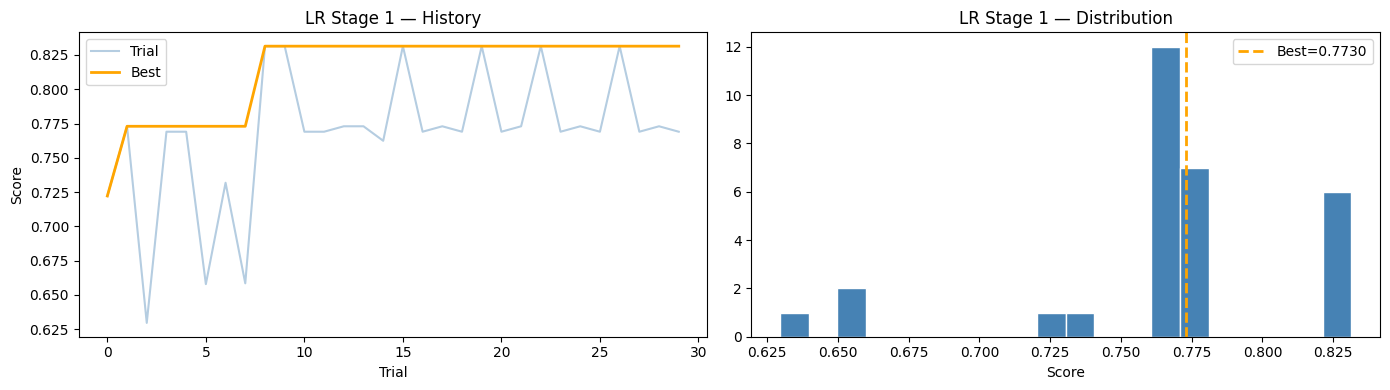

In [10]:
def objective_lr_s1(trial):
    params = {
        'C':           trial.suggest_float('C', 1e-3, 10.0, log=True),
        'solver':      trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'max_iter':    2000,
        'class_weight':'balanced',
        'random_state': SEED,
    }
    try:
        return ts_cv_score_s1(LogisticRegression(**params),
                              X_train_s1, y_train_s1, trial=trial)
    except optuna.exceptions.TrialPruned:
        raise

study_lr_s1 = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED),
                                   pruner=PRUNER)
study_lr_s1.optimize(objective_lr_s1, n_trials=N_TRIALS, show_progress_bar=True)
print(f'LR S1 best: {study_lr_s1.best_value:.4f}  params: {study_lr_s1.best_params}')
plot_optuna_history(study_lr_s1, 'LR Stage 1', 'plots/tuning/lr_s1.png')


### 3B. Random Forest

  0%|          | 0/30 [00:00<?, ?it/s]

RF S1 best: 0.7327  params: {'n_estimators': 212, 'max_depth': 10, 'min_samples_leaf': 38, 'min_samples_split': 13, 'max_features': 'sqrt'}


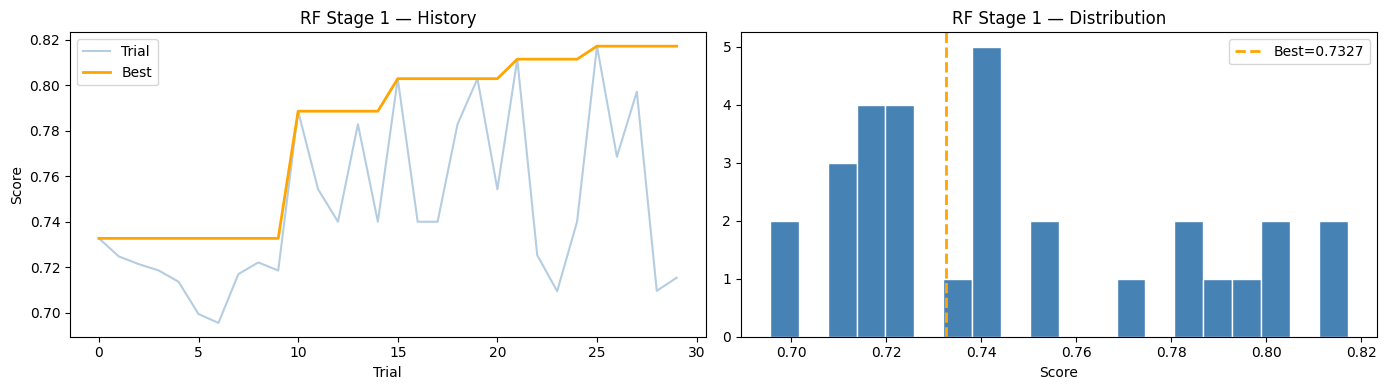

In [11]:
def objective_rf_s1(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 0.5, 0.7]),
        'class_weight':     'balanced',
        'random_state':      SEED,
        'n_jobs':            1,   # n_jobs=1 inside trial — Optuna manages parallelism
    }
    try:
        return ts_cv_score_s1(RandomForestClassifier(**params),
                              X_train_s1, y_train_s1, trial=trial)
    except optuna.exceptions.TrialPruned:
        raise

study_rf_s1 = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED),
                                   pruner=PRUNER)
study_rf_s1.optimize(objective_rf_s1, n_trials=N_TRIALS, show_progress_bar=True)
print(f'RF S1 best: {study_rf_s1.best_value:.4f}  params: {study_rf_s1.best_params}')
plot_optuna_history(study_rf_s1, 'RF Stage 1', 'plots/tuning/rf_s1.png')


### 3C. LightGBM

  0%|          | 0/30 [00:00<?, ?it/s]

LGB S1 best: 0.7206  params: {'n_estimators': 247, 'learning_rate': 0.01633944523707526, 'max_depth': 7, 'num_leaves': 90, 'min_child_samples': 64, 'colsample_bytree': 0.736061287588024, 'subsample': 0.6573034951676772, 'reg_alpha': 0.006966592646864171, 'reg_lambda': 0.003955292386203553}


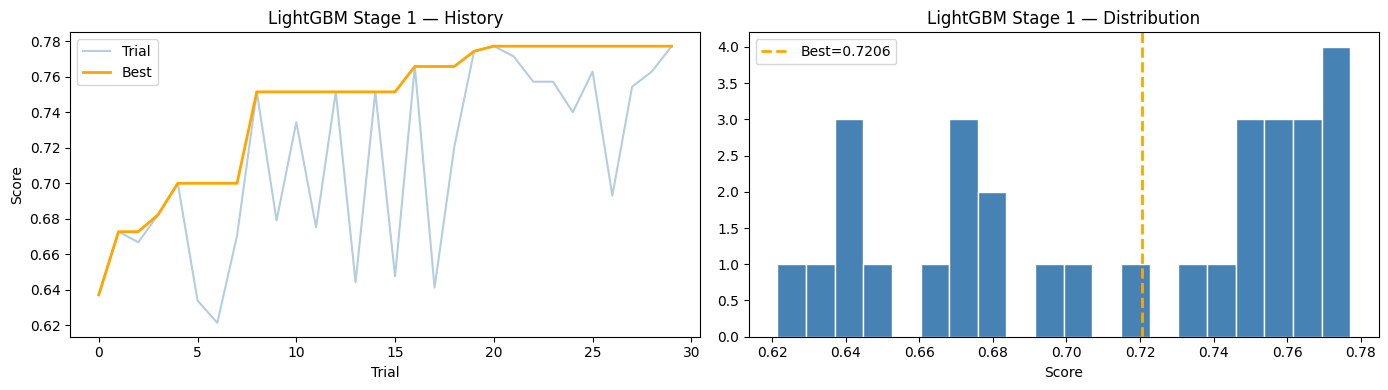

In [12]:
from sklearn.exceptions import DataConversionWarning

def objective_lgb_s1(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'class_weight':      'balanced',
        'random_state':       SEED,
        'n_jobs':             1,   # no nested parallelism inside trials
        'verbose':           -1,
    }
    try:
        return ts_cv_score_s1(lgb.LGBMClassifier(**params),
                              X_train_s1, y_train_s1, trial=trial)
    except optuna.exceptions.TrialPruned:
        raise

study_lgb_s1 = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED),
                                    pruner=PRUNER)
study_lgb_s1.optimize(objective_lgb_s1, n_trials=N_TRIALS, show_progress_bar=True)
print(f'LGB S1 best: {study_lgb_s1.best_value:.4f}  params: {study_lgb_s1.best_params}')
plot_optuna_history(study_lgb_s1, 'LightGBM Stage 1', 'plots/tuning/lgb_s1.png')


  0%|          | 0/30 [00:00<?, ?it/s]

XGB S1 best: 0.7023  params: {'n_estimators': 226, 'learning_rate': 0.01291291130698713, 'max_depth': 7, 'min_child_weight': 18, 'subsample': 0.8529760467940632, 'colsample_bytree': 0.940334305600578, 'reg_alpha': 0.412502734347756, 'reg_lambda': 0.09076226298386976}


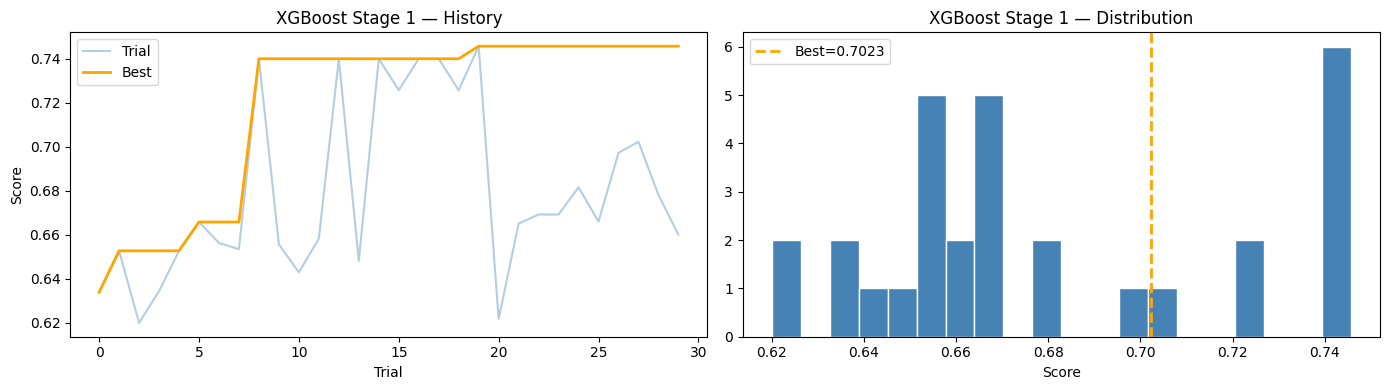

In [13]:
def objective_xgb_s1(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'use_label_encoder': False,
        'eval_metric':       'mlogloss',
        'random_state':       SEED, 'n_jobs': 1, 'verbosity': 0,
    }
    try:
        # XGB S1: no sample_weight — ts_cv_score_s1 just calls model.fit(X,y)
        return ts_cv_score_s1(xgb.XGBClassifier(**params),
                              X_train_s1, y_train_s1, trial=trial)
    except optuna.exceptions.TrialPruned:
        raise

study_xgb_s1 = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED),
                                    pruner=PRUNER)
study_xgb_s1.optimize(objective_xgb_s1, n_trials=N_TRIALS, show_progress_bar=True)
print(f'XGB S1 best: {study_xgb_s1.best_value:.4f}  params: {study_xgb_s1.best_params}')
plot_optuna_history(study_xgb_s1, 'XGBoost Stage 1', 'plots/tuning/xgb_s1.png')


### 3D. Retrain Stage 1 with Best Params & Evaluate

In [14]:
REGIME_NAMES = {0: 'Bullish', 1: 'Bearish', 2: 'High-Volatility'}

# Retrain on full training set with tuned params
best_lr_s1 = LogisticRegression(
    **study_lr_s1.best_params,
    max_iter=2000, class_weight='balanced', random_state=SEED
)
best_lr_s1.fit(X_train_s1, y_train_s1)

best_rf_s1 = RandomForestClassifier(
    **study_rf_s1.best_params,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
best_rf_s1.fit(X_train_s1, y_train_s1)

best_lgb_s1 = lgb.LGBMClassifier(
    **study_lgb_s1.best_params,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)
best_lgb_s1.fit(X_train_s1, y_train_s1)

best_xgb_s1 = xgb.XGBClassifier(
    **study_xgb_s1.best_params,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)
best_xgb_s1.fit(X_train_s1, y_train_s1)

s1_tuned_results = {
    'Logistic Regression': (y_test_s1, best_lr_s1.predict(X_test_s1)),
    'Random Forest': (y_test_s1, best_rf_s1.predict(X_test_s1)),
    'LightGBM': (y_test_s1, best_lgb_s1.predict(X_test_s1)),
    'XGBoost': (y_test_s1, best_xgb_s1.predict(X_test_s1)),
}

print('=== Stage 1 — Tuned Model Results ===')
for name, (yt, yp) in s1_tuned_results.items():
    print(f'\n--- {name} ---')
    print(classification_report(yt, yp, target_names=list(REGIME_NAMES.values())))

=== Stage 1 — Tuned Model Results ===

--- Logistic Regression ---
                 precision    recall  f1-score   support

        Bullish       0.89      0.74      0.80       307
        Bearish       0.55      0.54      0.55       152
High-Volatility       0.32      0.93      0.47        29

       accuracy                           0.69       488
      macro avg       0.59      0.74      0.61       488
   weighted avg       0.75      0.69      0.70       488


--- Random Forest ---
                 precision    recall  f1-score   support

        Bullish       0.91      0.70      0.79       307
        Bearish       0.56      0.64      0.60       152
High-Volatility       0.36      1.00      0.53        29

       accuracy                           0.70       488
      macro avg       0.61      0.78      0.64       488
   weighted avg       0.77      0.70      0.71       488


--- LightGBM ---
                 precision    recall  f1-score   support

        Bullish       0.83    

In [15]:
# ── Before vs After comparison table ──
# Baseline results from ModelTraining (hardcoded from your saved CSVs)
baseline_s1 = {
    'Logistic Regression': 0.6156,
    'Random Forest': 0.65,
    'LightGBM': 0.641,
    'XGBoost': 0.646,
}

comparison_s1 = pd.DataFrame([
    {
        'Model': name,
        'Baseline Macro F1': baseline_s1[name],
        'Tuned Macro F1': f1_score(yt, yp, average='macro'),
        'Delta': f1_score(yt, yp, average='macro') - baseline_s1[name],
    }
    for name, (yt, yp) in s1_tuned_results.items()
])

print('=== Stage 1 — Tuning Impact ===')
print(comparison_s1.to_string(index=False))

=== Stage 1 — Tuning Impact ===
              Model  Baseline Macro F1  Tuned Macro F1     Delta
Logistic Regression             0.6156        0.608207 -0.007393
      Random Forest             0.6500        0.638441 -0.011559
           LightGBM             0.6410        0.612351 -0.028649
            XGBoost             0.6460        0.642871 -0.003129


---
## 4. Update Stage 2 with Tuned Stage 1 Regime Predictions
Re-generate `regime_pred` using the best tuned Stage 1 model before tuning Stage 2.

In [16]:
# Pick best tuned S1 model by Macro F1
best_s1_name  = comparison_s1.loc[comparison_s1['Tuned Macro F1'].idxmax(), 'Model']
best_s1_model = {'Logistic Regression': best_lr_s1,
                 'Random Forest': best_rf_s1,
                 'LightGBM': best_lgb_s1,'XGBoost': best_xgb_s1}[best_s1_name]
print(f'Best Stage 1 model: {best_s1_name}')

# Re-map regime_pred using best tuned S1 model
X_all_s1_sc = scaler_s1.transform(stage1_df[S1_FEATURES].values)
regime_map   = dict(zip(stage1_df['Date'], best_s1_model.predict(X_all_s1_sc)))
df['regime_pred'] = df['Date'].map(regime_map).ffill().bfill().fillna(0).astype(int)

# Recompute only the 4 interaction features in S2_FEATURES_REGIME
df['Regime_Direction'] = df['regime_pred'].map({0: 1, 1: -1, 2: 0}).astype(float)
df['Regime_VolFlag']   = (df['regime_pred'] == 2).astype(float)
df['Dir_x_Ret5']       = df['Regime_Direction'] * df['Ret_5d']
df['Dir_x_RSI']        = df['Regime_Direction'] * (df['RSI'] / 100.0)
df['Vol_x_ATR']        = df['Regime_VolFlag']   * df['ATR_Pct']

assert 'regime_pred' in df.columns
missing = [c for c in S2_FEATURES_REGIME if c not in df.columns]
assert not missing, f'S2 columns missing: {missing}'

# Rebuild Stage 2 splits with updated regime_pred (keep y_return_5d for weights)
df_s2 = (df[S2_FEATURES_REGIME + ['Date', 'signal', 'y_return_5d']]
         .dropna().sort_values('Date').reset_index(drop=True))
split_date_s2 = df_s2['Date'].quantile(0.8)
train_s2 = df_s2[df_s2['Date'] <= split_date_s2]
test_s2  = df_s2[df_s2['Date'] >  split_date_s2]

scaler_s2  = StandardScaler()
X_train_s2 = scaler_s2.fit_transform(train_s2[S2_FEATURES_REGIME].values)
X_test_s2  = scaler_s2.transform(test_s2[S2_FEATURES_REGIME].values)
y_train_s2 = train_s2['signal'].values
y_test_s2  = test_s2['signal'].values

print(f'Stage 2 rebuilt with tuned regime_pred. Train: {X_train_s2.shape}')


Best Stage 1 model: XGBoost
Stage 2 rebuilt with tuned regime_pred. Train: (952633, 13)


---
## 5. Stage 2 Tuning — Stock-Level Classifier

### 5A. Logistic Regression

  0%|          | 0/30 [00:00<?, ?it/s]

LR S2 best: 0.4304  params: {'C': 0.024289169469748875, 'solver': 'lbfgs'}


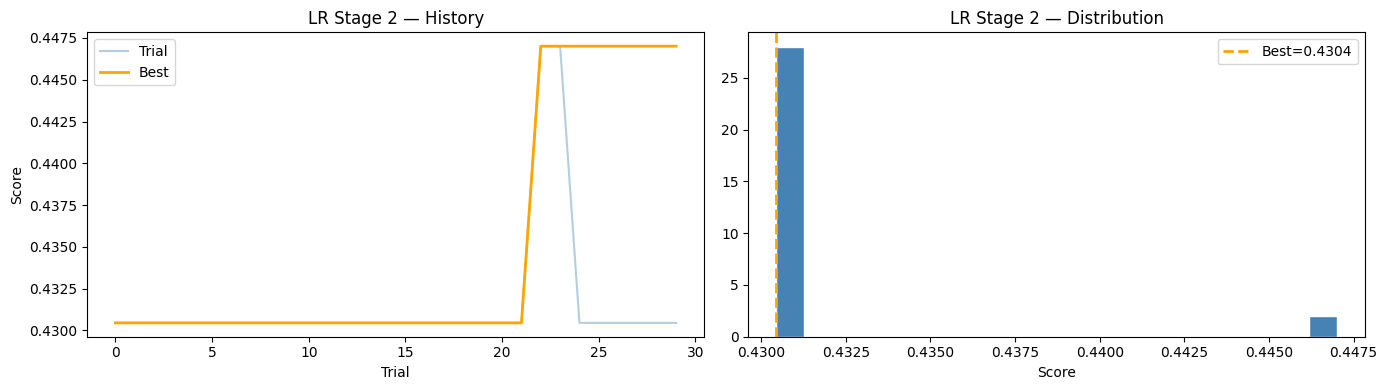

In [17]:
# SELL_BUY_WEIGHT fixed at 6.0 — Optuna tunes architecture only
SELL_BUY_WEIGHT = 6.0
CW = {0: SELL_BUY_WEIGHT, 1: 1.0, 2: SELL_BUY_WEIGHT}

def objective_lr_s2(trial):
    params = {
        'C':              trial.suggest_float('C', 1e-3, 5.0, log=True),
        'solver':         trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'max_iter':       2000,
        'class_weight':   CW,   # fixed 6× Sell/Buy — not tuned
        'random_state':    SEED,
    }
    try:
        return ts_cv_score_s2(LogisticRegression(**params),
                              X_train_s2, y_train_s2,
                              use_sw=False, trial=trial)
    except optuna.exceptions.TrialPruned:
        raise

study_lr_s2 = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED),
                                   pruner=PRUNER)
study_lr_s2.optimize(objective_lr_s2, n_trials=N_TRIALS, show_progress_bar=True)
print(f'LR S2 best: {study_lr_s2.best_value:.4f}  params: {study_lr_s2.best_params}')
plot_optuna_history(study_lr_s2, 'LR Stage 2', 'plots/tuning/lr_s2.png')


### 5B. Random Forest

  0%|          | 0/30 [00:00<?, ?it/s]

RF S2 best: 0.3872  params: {'n_estimators': 212, 'max_depth': 6, 'min_samples_leaf': 94, 'min_samples_split': 153, 'max_features': 0.7}


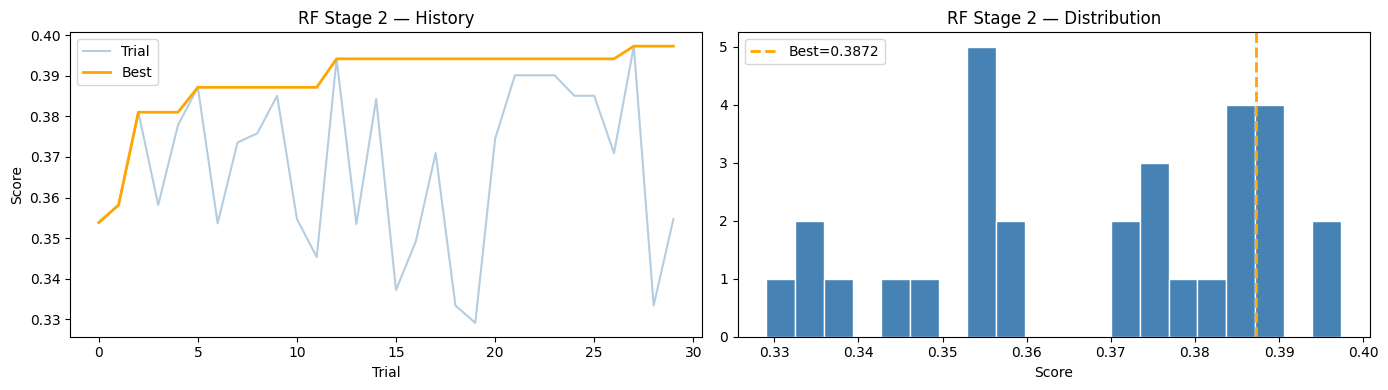

In [18]:
def objective_rf_s2(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 250),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 50, 500),
        'min_samples_split': trial.suggest_int('min_samples_split', 50, 200),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 0.5, 0.7]),
        'class_weight':       CW,   # fixed 6× Sell/Buy
        'random_state':       SEED, 'n_jobs': 1,
    }
    try:
        return ts_cv_score_s2(RandomForestClassifier(**params),
                              X_train_s2, y_train_s2,
                              use_sw=False, subsample=60_000, trial=trial)
    except optuna.exceptions.TrialPruned:
        raise

study_rf_s2 = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED),
                                   pruner=PRUNER)
study_rf_s2.optimize(objective_rf_s2, n_trials=N_TRIALS, show_progress_bar=True)
print(f'RF S2 best: {study_rf_s2.best_value:.4f}  params: {study_rf_s2.best_params}')
plot_optuna_history(study_rf_s2, 'RF Stage 2', 'plots/tuning/rf_s2.png')


### 5C. LightGBM

  0%|          | 0/30 [00:00<?, ?it/s]

LGB S2 best: 0.4434  params: {'n_estimators': 638, 'learning_rate': 0.08891965087341028, 'max_depth': 4, 'num_leaves': 107, 'min_child_samples': 86, 'colsample_bytree': 0.83139266557042, 'subsample': 0.8428590052757396, 'subsample_freq': 4, 'reg_alpha': 0.0002257518976697989, 'reg_lambda': 0.5032560121381049, 'min_split_gain': 0.03455234186923958}


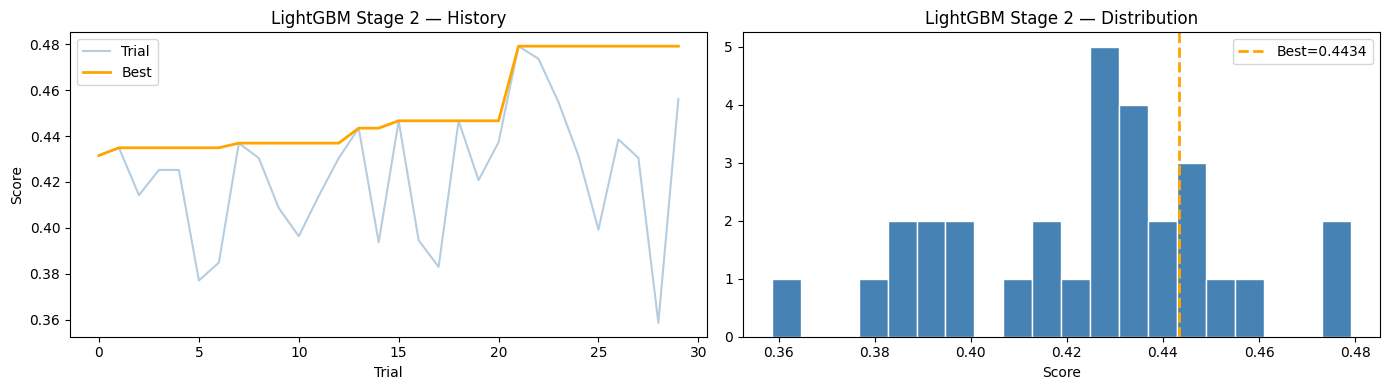

In [19]:
def objective_lgb_s2(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample':         trial.suggest_float('subsample', 0.4, 1.0),
        'subsample_freq':    trial.suggest_int('subsample_freq', 1, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 0.05),
        'class_weight':       CW,   # fixed 6× Sell/Buy
        'random_state':       SEED, 'n_jobs': 1, 'verbose': -1,
    }
    try:
        return ts_cv_score_s2(lgb.LGBMClassifier(**params),
                              X_train_s2, y_train_s2,
                              use_sw=False, trial=trial)
    except optuna.exceptions.TrialPruned:
        raise

study_lgb_s2 = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED),
                                    pruner=PRUNER)
study_lgb_s2.optimize(objective_lgb_s2, n_trials=N_TRIALS, show_progress_bar=True)
print(f'LGB S2 best: {study_lgb_s2.best_value:.4f}  params: {study_lgb_s2.best_params}')
plot_optuna_history(study_lgb_s2, 'LightGBM Stage 2', 'plots/tuning/lgb_s2.png')


### XGBoost Objectives
Same purged walk-forward CV + diagonal-weighted objective as LR/RF/LGB.

  0%|          | 0/30 [00:00<?, ?it/s]

XGB S2 best: 0.4840  params: {'n_estimators': 680, 'learning_rate': 0.0691272413108936, 'max_depth': 7, 'min_child_weight': 40, 'subsample': 0.8182252712853813, 'colsample_bytree': 0.9502029798295885, 'reg_alpha': 0.05666466565716491, 'reg_lambda': 0.11463716775118862, 'gamma': 0.14240036067667927}


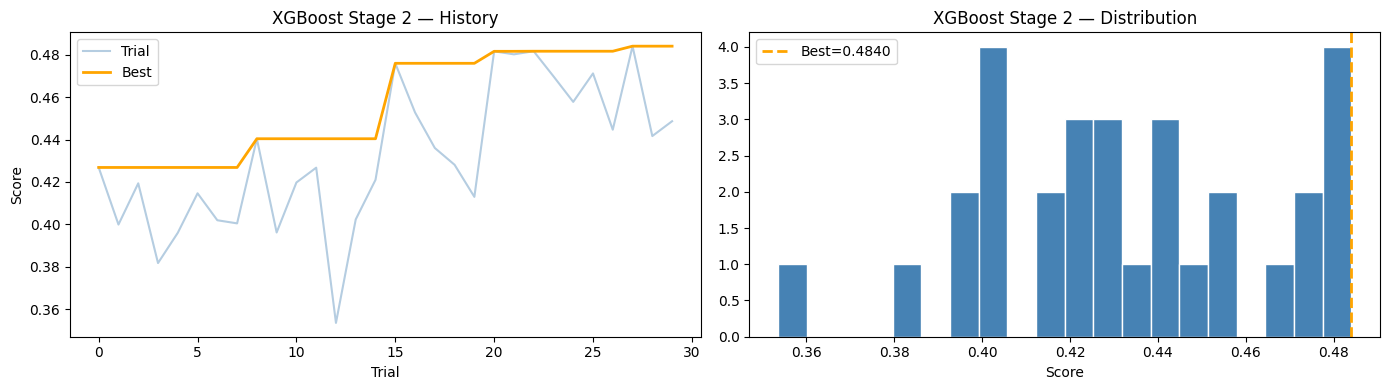

In [20]:
# XGBoost S2: use_sw=True — inv_freq_weights computed per fold inside ts_cv_score_s2
def objective_xgb_s2(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'min_child_weight':  trial.suggest_int('min_child_weight', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'gamma':             trial.suggest_float('gamma', 0.0, 0.5),
        'use_label_encoder': False, 'eval_metric': 'mlogloss',
        'random_state':       SEED, 'n_jobs': 1, 'verbosity': 0,
    }
    try:
        return ts_cv_score_s2(xgb.XGBClassifier(**params),
                              X_train_s2, y_train_s2,
                              use_sw=True, trial=trial)   # inv_freq per fold
    except optuna.exceptions.TrialPruned:
        raise

study_xgb_s2 = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED),
                                    pruner=PRUNER)
study_xgb_s2.optimize(objective_xgb_s2, n_trials=N_TRIALS, show_progress_bar=True)
print(f'XGB S2 best: {study_xgb_s2.best_value:.4f}  params: {study_xgb_s2.best_params}')
plot_optuna_history(study_xgb_s2, 'XGBoost Stage 2', 'plots/tuning/xgb_s2.png')


### 5D. Retrain Stage 2 with Best Params & Evaluate

In [21]:
SIGNAL_NAMES  = {0: 'Sell', 1: 'Hold', 2: 'Buy'}
REGIME_NAMES  = {0: 'Bullish', 1: 'Bearish', 2: 'High-Volatility'}

# ── Stage 1: fit with class_weight="balanced" (unchanged, correct) ────────────
best_lr_s1  = LogisticRegression(**{k:v for k,v in study_lr_s1.best_params.items()},
                                  max_iter=2000, class_weight='balanced', random_state=SEED)
best_rf_s1  = RandomForestClassifier(**study_rf_s1.best_params,
                                      class_weight='balanced', random_state=SEED, n_jobs=-1)
best_lgb_s1 = lgb.LGBMClassifier(**study_lgb_s1.best_params,
                                   class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1)
best_xgb_s1 = xgb.XGBClassifier(**{k:v for k,v in study_xgb_s1.best_params.items()},
                                   use_label_encoder=False, eval_metric='mlogloss',
                                   random_state=SEED, n_jobs=-1, verbosity=0)
for m in [best_lr_s1, best_rf_s1, best_lgb_s1, best_xgb_s1]:
    m.fit(X_train_s1, y_train_s1)
print('Stage 1 models fitted.')

# ── Stage 2: same weighting logic as ModelTraining v3 ────────────────────────
# sklearn models: class_weight in constructor, NO sample_weight in fit()
# XGBoost: inv_freq_weights() in fit(), no class_weight param

best_lr_s2 = LogisticRegression(
    **{k:v for k,v in study_lr_s2.best_params.items()},
    max_iter=2000, class_weight=CW, random_state=SEED
)
best_rf_s2 = RandomForestClassifier(
    **{k:v for k,v in study_rf_s2.best_params.items()
       if k not in ['class_weight']},
    class_weight=CW, random_state=SEED, n_jobs=-1
)
best_lgb_s2 = lgb.LGBMClassifier(
    **{k:v for k,v in study_lgb_s2.best_params.items()
       if k not in ['class_weight']},
    class_weight=CW, random_state=SEED, n_jobs=-1, verbose=-1
)
best_xgb_s2 = xgb.XGBClassifier(
    **{k:v for k,v in study_xgb_s2.best_params.items()},
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)

best_lr_s2.fit(X_train_s2, y_train_s2)
best_rf_s2.fit(X_train_s2, y_train_s2)
best_lgb_s2.fit(X_train_s2, y_train_s2)
best_xgb_s2.fit(X_train_s2, y_train_s2, sample_weight=inv_freq_weights(y_train_s2))

print(f'Stage 2 models fitted. SELL_BUY_WEIGHT={SELL_BUY_WEIGHT} (fixed).')
print('  LR/RF/LGB: class_weight=CW, no sample_weight')
print('  XGB: inv_freq_weights in fit(), no class_weight param')

# ── Evaluate: plain model.predict(), no threshold calibration ────────────────
s2_tuned_preds = {
    'Logistic Regression': best_lr_s2.predict(X_test_s2),
    'Random Forest':       best_rf_s2.predict(X_test_s2),
    'LightGBM':            best_lgb_s2.predict(X_test_s2),
    'XGBoost':             best_xgb_s2.predict(X_test_s2),
}

print("\n=== Stage 2 Tuned Results ===")
for name, yp in s2_tuned_preds.items():
    f1 = f1_score(y_test_s2, yp, average='macro')
    ba = balanced_accuracy_score(y_test_s2, yp)
    print(f"\n--- {name}  BalAcc={ba:.4f}  MacroF1={f1:.4f} ---")
    print(classification_report(y_test_s2, yp, target_names=['Sell','Hold','Buy'], digits=3))

s2_tuned_results = {name: (y_test_s2, yp) for name, yp in s2_tuned_preds.items()}

s1_tuned_results = {
    'Logistic Regression': (y_test_s1, best_lr_s1.predict(X_test_s1)),
    'Random Forest':       (y_test_s1, best_rf_s1.predict(X_test_s1)),
    'LightGBM':            (y_test_s1, best_lgb_s1.predict(X_test_s1)),
    'XGBoost':             (y_test_s1, best_xgb_s1.predict(X_test_s1)),
}
print("\n=== Stage 1 Tuned Results ===")
for name, (yt, yp) in s1_tuned_results.items():
    f1 = f1_score(yt, yp, average='macro')
    print(f"  {name}: Macro F1={f1:.4f}")


Stage 1 models fitted.
Stage 2 models fitted. SELL_BUY_WEIGHT=6.0 (fixed).
  LR/RF/LGB: class_weight=CW, no sample_weight
  XGB: inv_freq_weights in fit(), no class_weight param

=== Stage 2 Tuned Results ===

--- Logistic Regression  BalAcc=0.3609  MacroF1=0.2939 ---
              precision    recall  f1-score   support

        Sell      0.151     0.505     0.232     35927
        Hold      0.735     0.288     0.414    166049
         Buy      0.198     0.289     0.235     36001

    accuracy                          0.321    237977
   macro avg      0.361     0.361     0.294    237977
weighted avg      0.565     0.321     0.360    237977


--- Random Forest  BalAcc=0.3611  MacroF1=0.2590 ---
              precision    recall  f1-score   support

        Sell      0.151     0.600     0.242     35927
        Hold      0.739     0.186     0.297    166049
         Buy      0.199     0.298     0.239     36001

    accuracy                          0.265    237977
   macro avg      0.363 

---
## 6. Final Comparison — Baseline vs Tuned

In [22]:
# Baseline Stage 2 results from ModelTraining CSVs
baseline_s2 = {
    'Logistic Regression': 0.2582,
    'Random Forest': 0.2587,
    'LightGBM': 0.25,
    'XGBoost': 0.2765,
}

comparison_s2 = pd.DataFrame([
    {
        'Model': name,
        'Baseline Macro F1': baseline_s2[name],
        'Tuned Macro F1': f1_score(yt, yp, average='macro'),
        'Delta': f1_score(yt, yp, average='macro') - baseline_s2[name],
    }
    for name, (yt, yp) in s2_tuned_results.items()
])

print('=== Stage 1 Tuning Impact ===')
print(comparison_s1.to_string(index=False))
print()
print('=== Stage 2 Tuning Impact ===')
print(comparison_s2.to_string(index=False))

=== Stage 1 Tuning Impact ===
              Model  Baseline Macro F1  Tuned Macro F1     Delta
Logistic Regression             0.6156        0.608207 -0.007393
      Random Forest             0.6500        0.638441 -0.011559
           LightGBM             0.6410        0.612351 -0.028649
            XGBoost             0.6460        0.642871 -0.003129

=== Stage 2 Tuning Impact ===
              Model  Baseline Macro F1  Tuned Macro F1     Delta
Logistic Regression              0.351        0.293917 -0.057083
      Random Forest              0.338        0.258999 -0.079001
           LightGBM              0.341        0.285443 -0.055557
            XGBoost              0.342        0.352268  0.010268


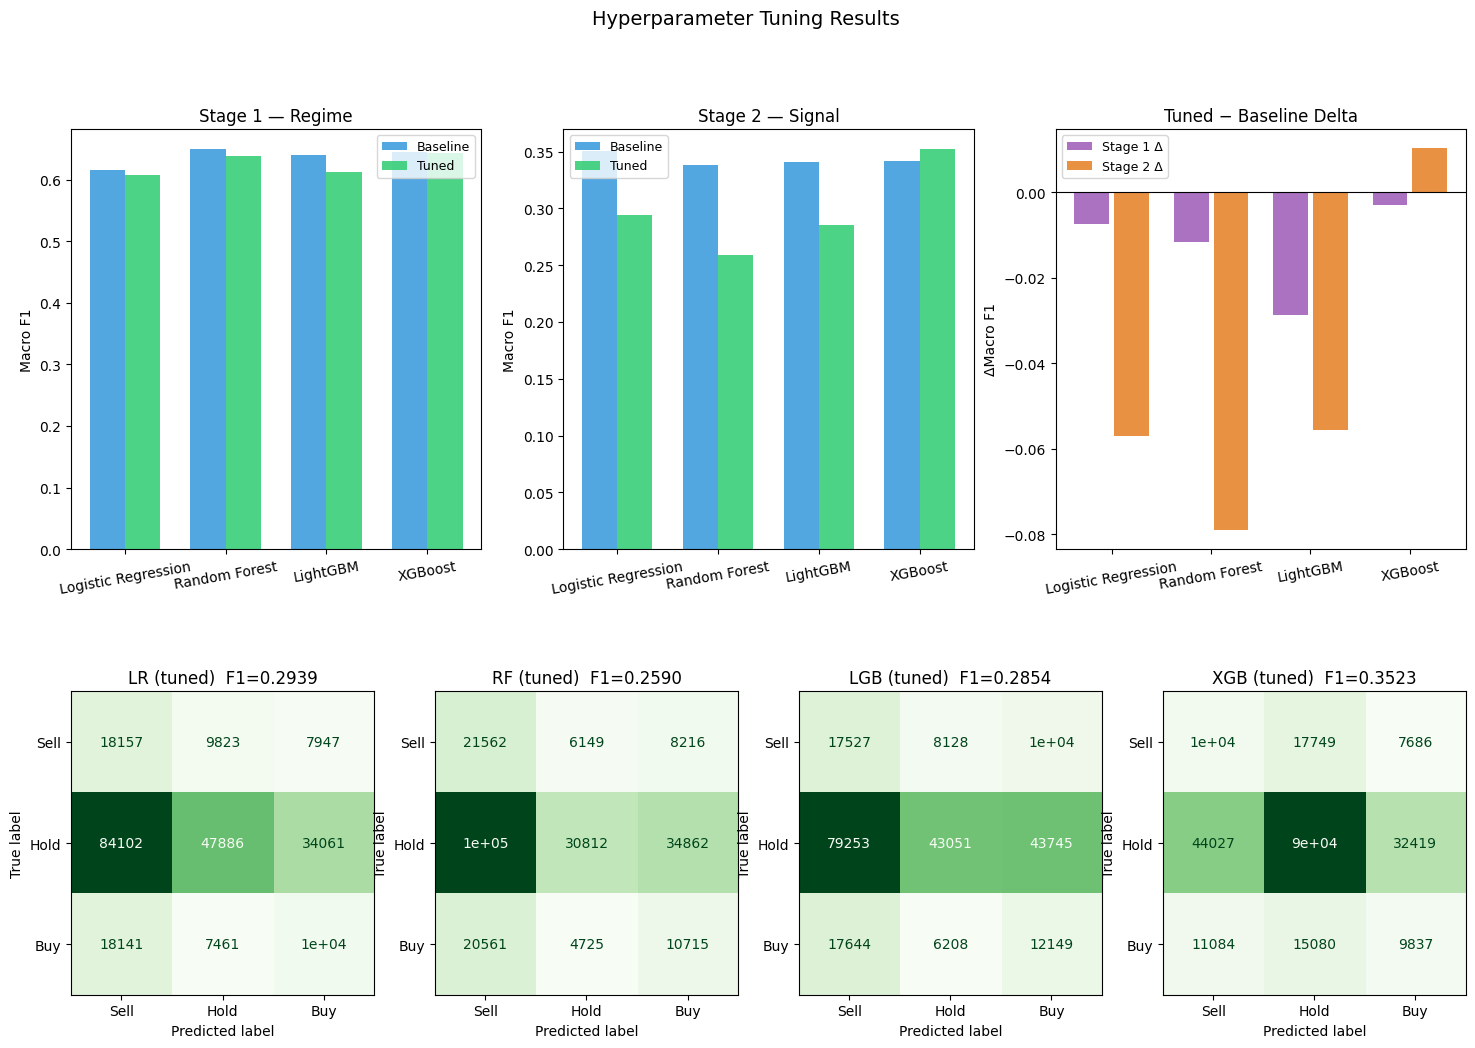

In [23]:
# ── Figure — Tuning Comparison + Confusion Matrices (2 rows) ─────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Hyperparameter Tuning Results', fontsize=14)

# Row 1: Baseline vs Tuned bar charts (S1 and S2)
ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)

for ax, (comp_df, title) in zip([ax1, ax2], [
    (comparison_s1, 'Stage 1 — Regime'),
    (comparison_s2, 'Stage 2 — Signal'),
]):
    x, w = np.arange(len(comp_df)), 0.35
    ax.bar(x - w/2, comp_df['Baseline Macro F1'], w,
           label='Baseline', color='#3498db', alpha=0.85)
    ax.bar(x + w/2, comp_df['Tuned Macro F1'],   w,
           label='Tuned',    color='#2ecc71', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(comp_df['Model'], rotation=10)
    ax.set_ylabel('Macro F1'); ax.set_title(title); ax.legend(fontsize=9)

# Δ plot
ax3 = fig.add_subplot(2, 3, 3)
all_models = list(comparison_s2['Model'])
delta_s1 = comparison_s1['Tuned Macro F1'].values - comparison_s1['Baseline Macro F1'].values
delta_s2 = comparison_s2['Tuned Macro F1'].values - comparison_s2['Baseline Macro F1'].values
x = np.arange(len(all_models))
ax3.bar(x - 0.2, delta_s1, 0.35, label='Stage 1 Δ', color='#9b59b6', alpha=0.85)
ax3.bar(x + 0.2, delta_s2, 0.35, label='Stage 2 Δ', color='#e67e22', alpha=0.85)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x); ax3.set_xticklabels(all_models, rotation=10)
ax3.set_ylabel('ΔMacro F1'); ax3.set_title('Tuned − Baseline Delta')
ax3.legend(fontsize=9)

# Row 2: S2 Confusion matrices (tuned models)
for idx, (name, model) in enumerate(zip(
    ['LR (tuned)', 'RF (tuned)', 'LGB (tuned)', 'XGB (tuned)'],
    [best_lr_s2, best_rf_s2, best_lgb_s2, best_xgb_s2]
)):
    ax = fig.add_subplot(2, 4, 5 + idx)
    yp = model.predict(X_test_s2)
    ConfusionMatrixDisplay(confusion_matrix(y_test_s2, yp),
                           display_labels=['Sell','Hold','Buy']
                          ).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{name}  F1={f1_score(y_test_s2, yp, average="macro"):.4f}')

plt.tight_layout()
plt.savefig('plots/tuning/fig_tuning_summary.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
print("Tuning figure saved above.")


Tuning figure saved above.


---
## 7. Save Everything

In [25]:
# Save tuned models
for name, model in [('lr_s1', best_lr_s1), ('rf_s1', best_rf_s1), ('lgb_s1', best_lgb_s1),
                    ('xgb_s1', best_xgb_s1),
                    ('lr_s2', best_lr_s2), ('rf_s2', best_rf_s2), ('lgb_s2', best_lgb_s2),
                    ('xgb_s2', best_xgb_s2)]:
    with open(f'models/tuned/{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

# Save scalers
with open('models/tuned/scaler_s1.pkl', 'wb') as f: pickle.dump(scaler_s1, f)
with open('models/tuned/scaler_s2.pkl', 'wb') as f: pickle.dump(scaler_s2, f)

# Save best params as JSON
best_params = {
    'stage1': {
        'logistic_regression': study_lr_s1.best_params,
        'random_forest':       study_rf_s1.best_params,
        'lightgbm':            study_lgb_s1.best_params,
        'xgboost':             study_xgb_s1.best_params,
    },
    'stage2': {
        'logistic_regression': study_lr_s2.best_params,
        'random_forest':       study_rf_s2.best_params,
        'lightgbm':            study_lgb_s2.best_params,
        'xgboost':             study_xgb_s2.best_params,
    }
}
with open('results/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

# Save comparison tables
comparison_s1.to_csv('results/tuning_comparison_s1.csv', index=False)
comparison_s2.to_csv('results/tuning_comparison_s2.csv', index=False)

print('All tuned models, params, and results saved.')
print(json.dumps(best_params, indent=2))

All tuned models, params, and results saved.
{
  "stage1": {
    "logistic_regression": {
      "C": 0.24810409748678114,
      "solver": "lbfgs"
    },
    "random_forest": {
      "n_estimators": 212,
      "max_depth": 10,
      "min_samples_leaf": 38,
      "min_samples_split": 13,
      "max_features": "sqrt"
    },
    "lightgbm": {
      "n_estimators": 247,
      "learning_rate": 0.01633944523707526,
      "max_depth": 7,
      "num_leaves": 90,
      "min_child_samples": 64,
      "colsample_bytree": 0.736061287588024,
      "subsample": 0.6573034951676772,
      "reg_alpha": 0.006966592646864171,
      "reg_lambda": 0.003955292386203553
    },
    "xgboost": {
      "n_estimators": 226,
      "learning_rate": 0.01291291130698713,
      "max_depth": 7,
      "min_child_weight": 18,
      "subsample": 0.8529760467940632,
      "colsample_bytree": 0.940334305600578,
      "reg_alpha": 0.412502734347756,
      "reg_lambda": 0.09076226298386976
    }
  },
  "stage2": {
    "logist